<a href="https://colab.research.google.com/github/adi23042008-byte/aiml-bootcamp-2026/blob/main/aiml_bootcamp_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [ ]:

marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")
print("Average:",average)

Class failed
Average: 43.0


In [ ]:
import pandas as pd

In [ ]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [ ]:
df.shape

(6, 5)

In [ ]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [ ]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [ ]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [ ]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [ ]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [ ]:
import matplotlib.pyplot as plt

HOMEWORK

Chart 1: Scatter Plot (Attendance vs. Total Score)
Objective: Help students see if there is a positive correlation between attending class and achieving higher overall grades.

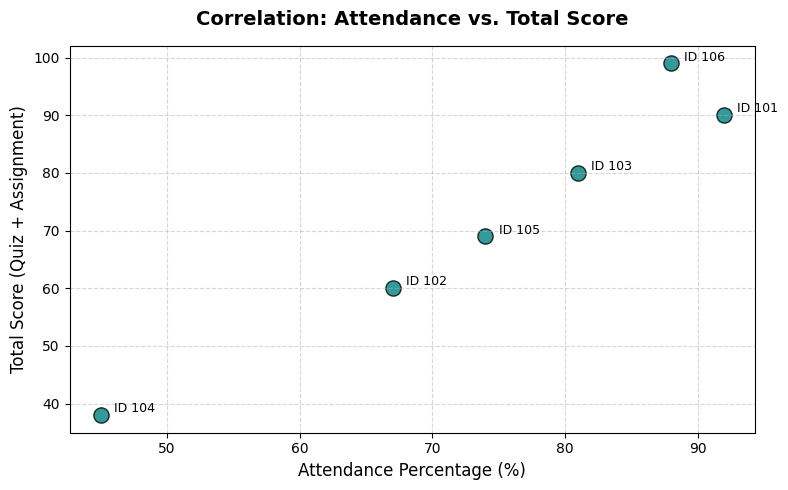

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['attendance_percent'], df['total_score'], color='teal', s=120, edgecolor='black', alpha=0.8)

# Annotate each point with the corresponding student ID
for i in range(len(df)):
    plt.annotate(f"ID {df['student_id'][i]}",
                 (df['attendance_percent'][i] + 1, df['total_score'][i] + 0.5),
                 fontsize=9)

plt.title('Correlation: Attendance vs. Total Score', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attendance Percentage (%)', fontsize=12)
plt.ylabel('Total Score (Quiz + Assignment)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Chart 2: Bar Chart (Lab Completion vs. Average Quiz Score)
Objective: Determine whether students who complete all lab exercises tend to score better on their quizzes.


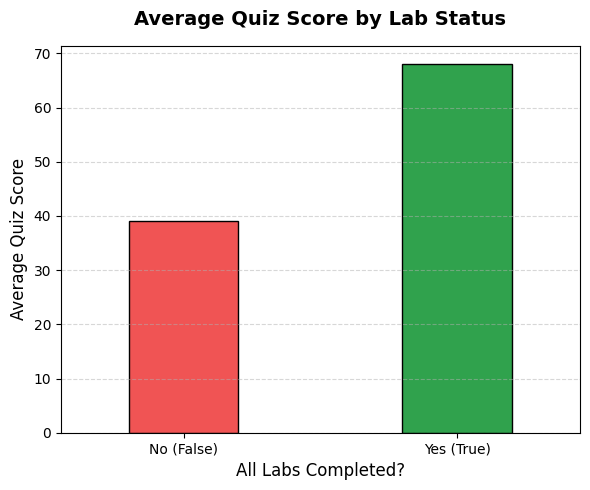

In [ ]:
# Grouping the data to find the average quiz score for each group
avg_quiz_by_lab = df.groupby('lab_completed')['quiz_score'].mean()

plt.figure(figsize=(6, 5))
# Customizing bar colors: Light Crimson for incomplete labs, Soft Mint for completed labs
colors = ['#f05454', '#30a24d']
avg_quiz_by_lab.plot(kind='bar', color=colors, edgecolor='black', width=0.4)

plt.title('Average Quiz Score by Lab Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('All Labs Completed?', fontsize=12)
plt.ylabel('Average Quiz Score', fontsize=12)
plt.xticks([0, 1], ['No (False)', 'Yes (True)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Chart 3: Pie Chart (Distribution of Attendance Categories)
Objective: Use a pie chart to visualize the overall proportion of the class across different attendance bands.

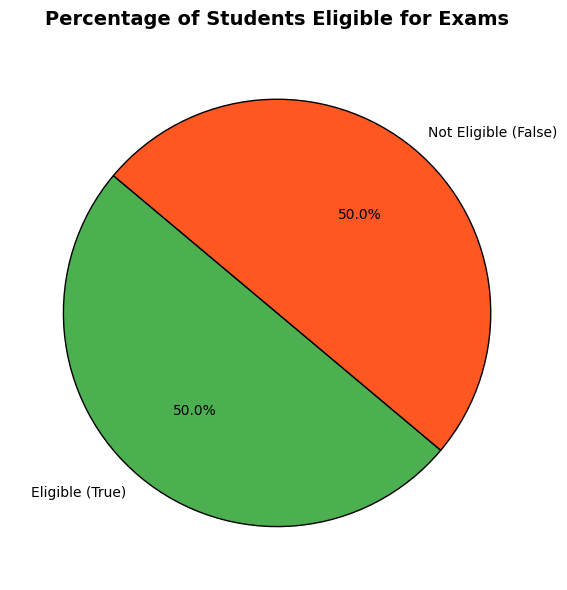

In [ ]:
# 1. Change this line to use your 'eligible' column
eligibility_counts = df['eligible'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(eligibility_counts,
        labels=['Eligible (True)', 'Not Eligible (False)'], # Updated labels to match your data
        autopct='%1.1f%%',
        startangle=140,
        colors=['#4CAF50', '#FF5722'], # Green for True, Red for False
        wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True})

# 2. Update the title to match your feature
plt.title('Percentage of Students Eligible for Exams', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

15 JUNE 2026

In [ ]:
subjects = ["Python", "Math", "AI", "Data"]

In [ ]:
print(subjects)
print(subjects[0])
print(subjects[-1])

['Python', 'Math', 'AI', 'Data']
Python
Data


In [ ]:
college = {
    "college_name": "GLA",
    "section": "CB",
    "city": "Mathura",
    "grades": ["A", "A+", "B", "B+"]
}

In [ ]:
students = [
    {   "name": "Adi Jain",
        "college_name": "GLA",
        "Class": "CB",
        "city": "mathura",
        "grade": "A"
    },
    {
        "name": "Harsh",
        "college_name": "IIT Delhi",
        "Class": "CS",
        "city": "Delhi",
        "grade": "A+"
    },
    {
        "name": "Ashish",
        "college_name": "NIT Trichy",
        "Class": "IT",
        "city": "Tiruchirappalli",
        "grade": "B+"
    },
    {
        "name": "Rahul",
        "college_name": "BHU",
        "Class": "EE",
        "city": "Varanasi",
        "grade": "B"
    },
    {
        "name": "Jagdish",
        "college_name": "DTU",
        "Class": "ME",
        "city": "Delhi",
        "grade": "A"
    }
]
for student in students:
    if student["grade"] == "A+":
        print(student)

{'name': 'Harsh', 'college_name': 'IIT Delhi', 'Class': 'CS', 'city': 'Delhi', 'grade': 'A+'}


In [ ]:
marks = 72

if marks>=80:
  print("distinction")
elif marks>=40 and marks<=79:
  print("pass")
else:
  print('fail')


pass


In [ ]:
if marks %2==0:
    print("even marks")
else:
    print("odd marks")


even marks


In [1]:
age=int(input())
if age<13:
  print("child")
elif age>13 and age<19:
  print("teenager")
else:
  print("Old")

33
Old


In [ ]:
students_list = [
    {
        "name": "Adi Jain",
        "age": 12,
        "attendance": 92,
        "marks": 85,
        "lab_assignment": True
    },
    {
        "name": "Raj Gupta",
        "age": 15,
        "attendance": 95,
        "marks": 92,
        "lab_assignment": True
    },
    {
        "name": "Rahul Verma",
        "age": 21,
        "attendance": 78,
        "marks": 64,
        "lab_assignment": False
    },
    {
        "name": "Priya Rai",
        "age": 19,
        "attendance":  88,
        "marks": 78,
        "lab_assignment": True
    },
    {
        "name": "Vikram Singh",
        "age": 11,
        "attendance": 60,
        "marks": 45,
        "lab_assignment": False
    }
]
for student in students_list:
    if student["lab_assignment"] == False:
        result = "Lab Assignment Not Submitted"
    elif student["attendance"] < 75:
        result = "Low Attendance"
    elif student["marks"] >= 70:
        result = "Distinction"
    elif student["marks"] >= 40:
        result = "Pass"
    else:
        result = "Fail"

    print(student["name"], "-", result)

16 JUNE 2026


In [ ]:
marks = int(input("Enter marks: "))
def result(marks):
    if marks>=40:
        print("Pass")
    else:
        print("Fail")
result(marks)

In [ ]:
import numpy as np
marks = np.array([78,84,62])
print(marks+10)

In [ ]:
import numpy as np
arr = np.array([10,20,30,40])
print(arr)
print(arr.shape)
matrix = np.array([[10,20,30],
                  [40,50,60]])
print(matrix)
print(matrix.shape)

In [ ]:
marks = np.array([78,91,55,72,40,88])
arr_2d = marks.reshape(2, 3)
print(arr_2d)

In [3]:
import pandas as pd
df = pd.read_csv('/session4_dummy_students_data.csv.xls')
df.head()

,student_id,name,age,city,math,science,english,attendance_percent,study_hours_per_week,assignments_submitted,final_project_score
0,101,Aarav,16,Mumbai,78,84,69,92,8,9,82
1,102,Diya,16,Delhi,91,88,94,96,11,10,93
2,103,Kabir,17,Mathura,55,61,58,75,5,6,60
3,104,Meera,16,Noida,72,79,81,89,7,8,78
4,105,Rohan,17,Mumbai,40,52,47,68,3,5,45


In [8]:
import pandas as pd
df = pd.read_csv('/session4_dummy_students_data.csv.xls')
df['average'] = (df['math'] + df['science'] + df['english']) / 3
top_students = df[df['average'] > 85]
low_attendance = top_students[top_students['attendance_percent'] < 75]
mathura_students = low_attendance[low_attendance['city'] == 'Mathura']
print(df[['name', 'average']])
print(mathura_students)
print(top_students)

      name    average
0    Aarav  77.000000
1     Diya  91.000000
2    Kabir  58.000000
3    Meera  77.333333
4    Rohan  46.333333
5     Sara  90.333333
6   Ishaan  66.666667
7   Ananya  92.000000
8   Vivaan  52.000000
9     Tara  81.333333
10   Arjun  67.333333
11   Nisha  78.000000
12     Dev  40.666667
13   Priya  88.666667
14   Kunal  57.333333
15    Riya  92.666667
16      Om  65.000000
17   Aditi  82.666667
18    Yash  46.000000
19   Sneha  76.666667
Empty DataFrame
Columns: [student_id, name, age, city, math, science, english, attendance_percent, study_hours_per_week, assignments_submitted, final_project_score, average]
Index: []
    student_id    name  age   city  math  science  english  \
1          102    Diya   16  Delhi    91       88       94   
5          106    Sara   16  Delhi    88       93       90   
7          108  Ananya   16  Noida    95       92       89   
13         114   Priya   16  Delhi    89       86       91   
15         116    Riya   16  Noida    92    

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv('/session4_dummy_students_data.csv.xls')
df["average"] = df[["math", "science", "english"]].mean(axis=1)
df["result"] = np.where(df["average"] >= 40, "Pass", "Fail")

class_avg = df["average"].mean()
print(f"Class Average: {class_avg:.2f}")

highest_avg = df["average"].max()
lowest_avg = df["average"].min()
print(f"Highest Average: {highest_avg:.2f}")
print(f"Lowest Average: {lowest_avg:.2f}")

top_students = df[df["average"] == highest_avg]
print("Top Student(s) ")
print(top_students[["name", "average"]])

low_attendance = df[df["attendance_percent"] < 75]
print("Students with Attendance Below 75% ")
print(low_attendance[["name", "attendance_percent"]])

few_assignments = df[df["assignments_submitted"] < 6]
print("Students with Fewer Than 6 Assignments")
print(few_assignments[["name", "assignments_submitted"]])

df.to_csv('session4_student_report.csv', index=False)
print("File saved successfully as 'session4_student_report.csv'")

Class Average: 71.35
Highest Average: 92.67
Lowest Average: 40.67
Top Student(s) 
    name    average
15  Riya  92.666667
Students with Attendance Below 75% 
      name  attendance_percent
4    Rohan                  68
8   Vivaan                  71
12     Dev                  62
18    Yash                  66
Students with Fewer Than 6 Assignments
     name  assignments_submitted
4   Rohan                      5
12    Dev                      4
18   Yash                      5
File saved successfully as 'session4_student_report.csv'


• Find the average final_project_score. • Find students with study_hours_per_week greater than 8. • Compare average marks of Mumbai students and Pune students. • Create a new column called performance_level. • Save only selected columns to a new CSV.

HOMEWORK

In [14]:
avg_project = df['final_project_score'].mean()
print("Average Final Project Score:", round(avg_project, 2))

Average Final Project Score: 73.65


In [15]:
students = df[df['study_hours_per_week'] > 8]
print("Students who study more than 8 hours per week:")
print(students[['name', 'study_hours_per_week']])

Students who study more than 8 hours per week:
      name  study_hours_per_week
1     Diya                    11
5     Sara                    10
7   Ananya                    12
9     Tara                     9
13   Priya                    10
15    Riya                    13
17   Aditi                     9


In [16]:
df['average'] = (df['math'] + df['science'] + df['english']) / 3

mumbai_avg = df[df['city'] == 'Mumbai']['average'].mean()
pune_avg = df[df['city'] == 'Pune']['average'].mean()

print("Mumbai Average:", round(mumbai_avg, 2))
print("Pune Average:", round(pune_avg, 2))

Mumbai Average: 56.2
Pune Average: nan


In [17]:
df['performance_level'] = df['average'].apply(
    lambda x: 'Excellent' if x >= 80
    else 'Good' if x >= 60
    else 'Needs Improvement'
)

print(df[['name', 'average', 'performance_level']])

      name    average  performance_level
0    Aarav  77.000000               Good
1     Diya  91.000000          Excellent
2    Kabir  58.000000  Needs Improvement
3    Meera  77.333333               Good
4    Rohan  46.333333  Needs Improvement
5     Sara  90.333333          Excellent
6   Ishaan  66.666667               Good
7   Ananya  92.000000          Excellent
8   Vivaan  52.000000  Needs Improvement
9     Tara  81.333333          Excellent
10   Arjun  67.333333               Good
11   Nisha  78.000000               Good
12     Dev  40.666667  Needs Improvement
13   Priya  88.666667          Excellent
14   Kunal  57.333333  Needs Improvement
15    Riya  92.666667          Excellent
16      Om  65.000000               Good
17   Aditi  82.666667          Excellent
18    Yash  46.000000  Needs Improvement
19   Sneha  76.666667               Good


In [18]:
new_df = df[['name', 'city', 'average', 'performance_level']]
new_df.to_csv('student_performance.csv', index=False)

print("File saved successfully as 'student_performance.csv'")

File saved successfully as 'student_performance.csv'


17 JUNE 2026

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())


       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [20]:
df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)

       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [21]:
print("Missing values in each column:")
print(df.isna().sum)

print("Number of duplicate rows:", df.duplicated().sum())

Missing values in each column:
<bound method DataFrame.sum of       country   year  population  continent  life_expectancy  gdp_per_capita
0       False  False       False      False            False           False
1       False  False       False      False            False           False
2       False  False       False      False            False           False
3       False  False       False      False            False           False
4       False  False       False      False            False           False
...       ...    ...         ...        ...              ...             ...
1699    False  False       False      False            False           False
1700    False  False       False      False            False           False
1701    False  False       False      False            False           False
1702    False  False       False      False            False           False
1703    False  False       False      False            False           False

[1704 rows x 

In [23]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())

country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106


In [ ]:
dirty_demo = df_clean.head(12).copy()

# Deliberately introduce missing values for teaching practice
dirty_demo.loc[2, "life_expectancy"] = np.nan
dirty_demo.loc[5, "gdp_per_capita"] = np.nan

print(dirty_demo)
print(dirty_demo.isna().sum())

# Fill missing numerical values using median
clean_demo = dirty_demo.copy()
clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

print(clean_demo.isna().sum())
print(clean_demo)


   student_id  attendance_percent  assignment_score  quiz_score  \
0         101                  92                18          72   
1         102                  67                12          48   
2         103                  81                15          65   
3         104                  45                 8          30   
4         105                  74                14          55   
5         106                  88                19          80   

   lab_completed  total_score  eligible  life_expectancy  gdp_per_capita  
0           True           90      True              NaN             NaN  
1          False           60     False              NaN             NaN  
2           True           80      True              NaN             NaN  
3          False           38     False              NaN             NaN  
4           True           69     False              NaN             NaN  
5           True           99      True              NaN             NaN  
stude

In [ ]:
import pandas as pd

# 1. Load the dataset from the remote URL
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# 2. Extract and print basic statistics
# Year Range
min_year = df['year'].min()
max_year = df['year'].max()

# Number of Unique Countries
num_countries = df['country'].nunique()

# Number of Unique Continents
num_continents = df['continent'].nunique()

# 3. Output the results
print(f"Year Range: {min_year} to {max_year}")
print(f"Number of unique countries: {num_countries}")
print(f"Number of unique continents: {num_continents}")

Year Range: 1952 to 2007
Number of unique countries: 142
Number of unique continents: 5


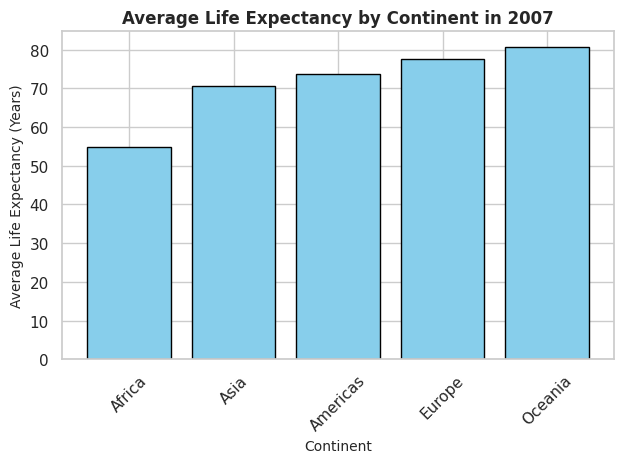

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# 2. Identify the latest year and filter the data
latest_year = df['year'].max()
latest_df = df[df['year'] == latest_year]

# 3. Calculate average life expectancy per continent and sort them
continent_life = latest_df.groupby("continent")["lifeExp"].mean().sort_values()

# 4. Create the Bar Chart
plt.bar(continent_life.index, continent_life.values, color='skyblue', edgecolor='black')

# 5. Add details and labels
plt.title(f"Average Life Expectancy by Continent in {latest_year}", fontsize=12, fontweight='bold')
plt.xlabel("Continent", fontsize=10)
plt.ylabel("Average Life Expectancy (Years)", fontsize=10)
plt.xticks(rotation=45)

# 6. Optimize and display
plt.tight_layout()
plt.show()

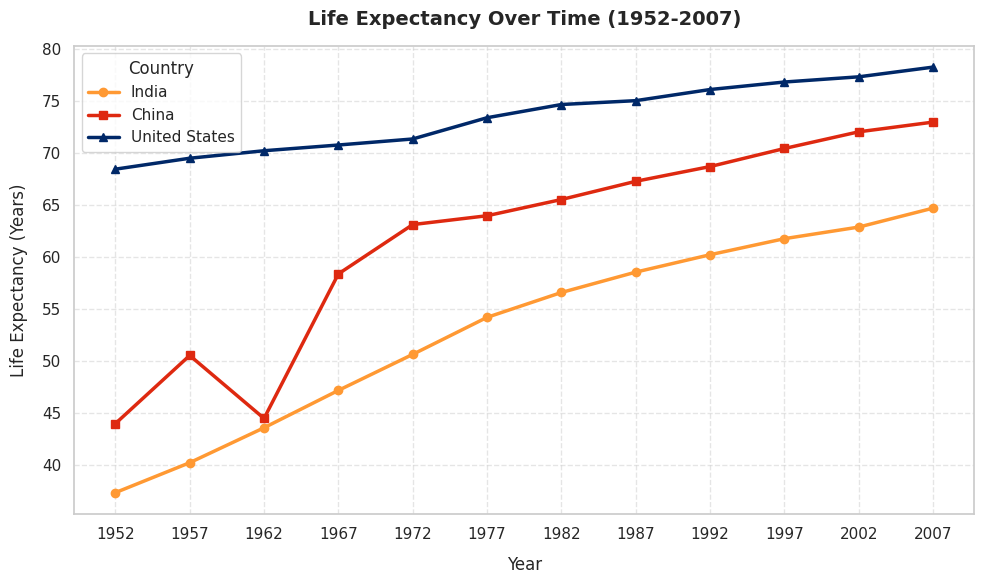

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# 2. Define the target countries
# Note: The dataset labels the USA as 'United States'
target_countries = ['India', 'China', 'United States']

# 3. Filter the DataFrame for only these three countries
filtered_df = df[df['country'].isin(target_countries)]

# 4. Initialize the plot figure
plt.figure(figsize=(10, 6))

# 5. Loop through each country to plot its line individually
colors = {'India': '#FF9933', 'China': '#DE2910', 'United States': '#002868'}
markers = {'India': 'o', 'China': 's', 'United States': '^'}

for country in target_countries:
    # Isolate data for the specific country
    country_data = filtered_df[filtered_df['country'] == country]

    # Plot year vs life expectancy
    plt.plot(
        country_data['year'],
        country_data['lifeExp'],
        marker=markers[country],
        linewidth=2.5,
        color=colors[country],
        label=country
    )

# 6. Customize chart elements
plt.title('Life Expectancy Over Time (1952-2007)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Life Expectancy (Years)', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Ensure all recorded data years show explicitly on the x-axis
plt.xticks(filtered_df['year'].unique())

# Add a legend to distinguish the lines
plt.legend(title='Country', fontsize=11, title_fontsize=12, loc='upper left')

# 7. Optimize layout and display
plt.tight_layout()
plt.show()

Life expectancy in China fell sharply between 1960 and 1962 due to the Great Chinese Famine.



The drop in life expectancy in 1959–1961 was caused by mass starvation, disease, and social disruption resulting from the Great Leap Forward’s policy failures, poor agricultural management, and adverse weather, leading to 15–30 million excess deaths

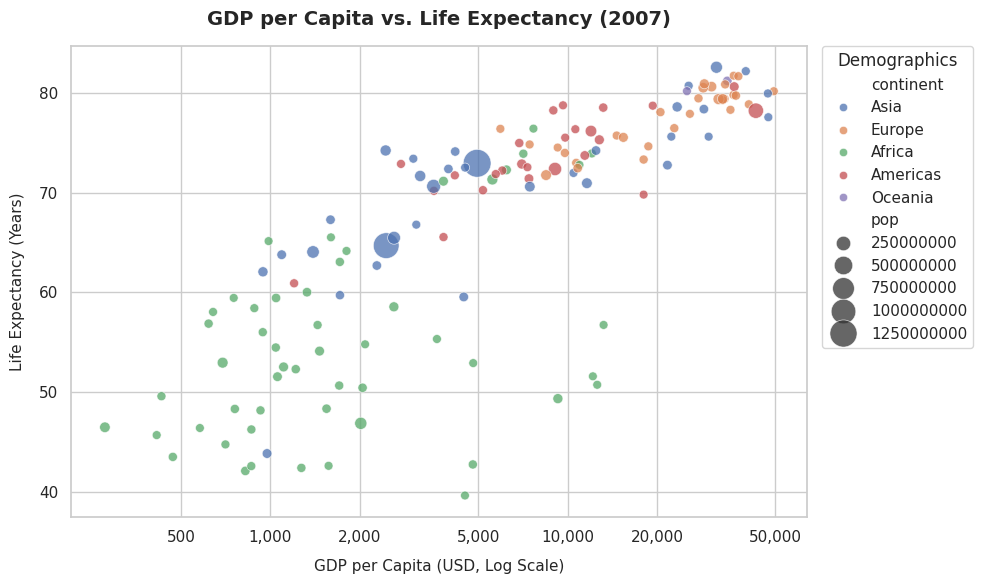

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

# 1. Load the dataset from the remote URL
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# 2. Filter for the latest year (2007) to capture the modern global snapshot
latest_year = df['year'].max()
latest_df = df[df['year'] == latest_year]

# 3. Configure layout options without using .figure()
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# 4. Generate the scatter plot
# Colors indicate continents; size can optionally represent population
ax = sns.scatterplot(
    data=latest_df,
    x='gdpPercap',
    y='lifeExp',
    hue='continent',
    size='pop',
    sizes=(40, 400),
    alpha=0.75,
    edgecolor='w'
)

# 5. Apply a Logarithmic Scale to the X-axis (GDP per capita increases exponentially)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ScalarFormatter())

# Clean up horizontal labels to avoid scientific notation formatting
plt.xticks(
    [500, 1000, 2000, 5000, 10000, 20000, 50000],
    ['500', '1,000', '2,000', '5,000', '10,000', '20,000', '50,000']
)

# 6. Titles and Axes Labels
plt.title(f'GDP per Capita vs. Life Expectancy ({latest_year})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('GDP per Capita (USD, Log Scale)', fontsize=11, labelpad=10)
plt.ylabel('Life Expectancy (Years)', fontsize=11, labelpad=10)

# Move the legend outside or position inside neatly
plt.legend(title='Demographics', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# 7. Final adjustments and rendering
plt.tight_layout()
plt.show()

Life expectancy increased steadily in India, China, and the United States from 1952 to 2007.
The United States maintained the highest life expectancy throughout the period.

indicates improvements in health, living conditions, and socioeconomic development over time.